 # MiniTetris



 >- **NAME: Yashar Zafari Haqqi**

 >- **STUDENT ID: 404210253**



 In this notebook the goal is to make the geometry of natural policy gradient visible in a Tetris-like control problem. The environment has many legal placements at each state, and the policy is a softmax over hand-designed afterstate features.



 We will compare two update directions:



 $$

 d_{\mathrm{PG}} = g,

 \qquad

 d_{\mathrm{NPG}} = (F+\lambda I)^{-1}g,

 $$



 where $g$ estimates the policy gradient and $F$ estimates the Fisher information matrix of the policy.



 The notebook therefore includes both training curves and geometric visualizations: KL-scaled updates, an empirical return landscape in the PG/NPG plane, and the greedy-action limit for the compatible function approximator.



In [1]:
import math
import time
import itertools
import warnings
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False
    Parallel = None
    delayed = None

np.set_printoptions(precision=4, suppress=True)



In [2]:
# -----------------------------
# Global experiment knobs
# -----------------------------

HEIGHT = 10
WIDTH = 10
MAX_STEPS = 300

BATCH_EPISODES = 64

N_ITER_PG_RAW = 400
N_ITER_NPG_RAW = 200
N_ITER_PG_KL = 400
N_ITER_NPG_KL = 200

ALPHA_PG_RAW = 0.005
ALPHA_NPG_RAW = 1.0

SEED = 7
rng = np.random.default_rng(SEED)

PARALLEL_ROLLOUTS = True
N_JOBS = -1

DAMPING = 1e-2
TARGET_KL = 0.02

print(dict(
    HEIGHT=HEIGHT, WIDTH=WIDTH, MAX_STEPS=MAX_STEPS, BATCH_EPISODES=BATCH_EPISODES,
    N_ITER_PG_RAW=N_ITER_PG_RAW, N_ITER_NPG_RAW=N_ITER_NPG_RAW,
    N_ITER_PG_KL=N_ITER_PG_KL, N_ITER_NPG_KL=N_ITER_NPG_KL,
    ALPHA_PG_RAW=ALPHA_PG_RAW, ALPHA_NPG_RAW=ALPHA_NPG_RAW,
    DAMPING=DAMPING, TARGET_KL=TARGET_KL,
    PARALLEL_ROLLOUTS=PARALLEL_ROLLOUTS, N_JOBS=N_JOBS,
    JOBLIB_AVAILABLE=JOBLIB_AVAILABLE
))

{'HEIGHT': 10, 'WIDTH': 10, 'MAX_STEPS': 300, 'BATCH_EPISODES': 64, 'N_ITER_PG_RAW': 400, 'N_ITER_NPG_RAW': 200, 'N_ITER_PG_KL': 400, 'N_ITER_NPG_KL': 200, 'ALPHA_PG_RAW': 0.005, 'ALPHA_NPG_RAW': 1.0, 'DAMPING': 0.01, 'TARGET_KL': 0.02, 'PARALLEL_ROLLOUTS': True, 'N_JOBS': -1, 'JOBLIB_AVAILABLE': False}


 ## 1. A Tetris-like MDP



 We implement a compact Tetris environment.



 State:

 - A binary board.

 - A current piece.



 Action:

 - Choose one legal placement of the current piece.

 - The piece is dropped vertically.

 - Full rows are cleared.



 Reward:

 - The reward is the line-clearing score from the resulting board.



 Policy:

 - For every legal placement, compute an afterstate feature vector $\phi_{s,a}$.

 - Use a softmax policy:

 $$

 \pi_\theta(a|s)

 =

 \frac{\exp(\theta^\top \phi_{s,a})}{\sum_b \exp(\theta^\top \phi_{s,b})}.

 $$



 This is the exponential-family form used in the theory.



In [3]:
# -----------------------------
# Tetromino definitions
# Coordinates are (row, col), normalized so min row = min col = 0.
# -----------------------------

RAW_PIECES = {
    "I": np.array([[0,0], [0,1], [0,2], [0,3]]),
    "O": np.array([[0,0], [0,1], [1,0], [1,1]]),
    "T": np.array([[0,1], [1,0], [1,1], [1,2]]),
    "S": np.array([[0,1], [0,2], [1,0], [1,1]]),
    "Z": np.array([[0,0], [0,1], [1,1], [1,2]]),
    "J": np.array([[0,0], [1,0], [1,1], [1,2]]),
    "L": np.array([[0,2], [1,0], [1,1], [1,2]]),
}

PIECE_NAMES = list(RAW_PIECES.keys())

def normalize_shape(coords: np.ndarray) -> np.ndarray:
    coords = coords.copy()
    coords[:,0] -= coords[:,0].min()
    coords[:,1] -= coords[:,1].min()
    # Sort for uniqueness
    coords = coords[np.lexsort((coords[:,1], coords[:,0]))]
    return coords

def rotate_shape(coords: np.ndarray) -> np.ndarray:
    # Rotate 90 degrees clockwise around origin, then normalize.
    r, c = coords[:,0], coords[:,1]
    rotated = np.stack([c, -r], axis=1)
    return normalize_shape(rotated)

def unique_rotations(coords: np.ndarray) -> List[np.ndarray]:
    rots = []
    seen = set()
    cur = normalize_shape(coords)
    for _ in range(4):
        key = tuple(map(tuple, cur.tolist()))
        if key not in seen:
            seen.add(key)
            rots.append(cur)
        cur = rotate_shape(cur)
    return rots

PIECES = [unique_rotations(RAW_PIECES[name]) for name in PIECE_NAMES]

for name, rots in zip(PIECE_NAMES, PIECES):
    print(name, "rotations:", len(rots))



I rotations: 2
O rotations: 1
T rotations: 4
S rotations: 2
Z rotations: 2
J rotations: 4
L rotations: 4


legal T placements on empty board: 34


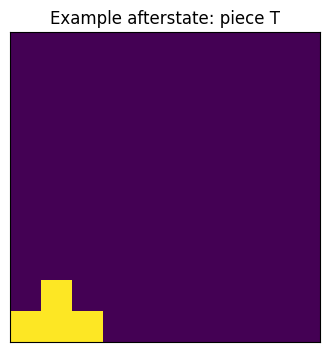

In [4]:
# -----------------------------
# Board mechanics
# -----------------------------

def empty_board(height=HEIGHT, width=WIDTH) -> np.ndarray:
    return np.zeros((height, width), dtype=np.int8)

def shape_height(shape):
    return int(shape[:,0].max() + 1)

def shape_width(shape):
    return int(shape[:,1].max() + 1)

def can_place(board: np.ndarray, shape: np.ndarray, y: int, x: int) -> bool:
    H, W = board.shape
    for dy, dx in shape:
        r, c = y + int(dy), x + int(dx)
        if r < 0 or r >= H or c < 0 or c >= W:
            return False
        if board[r, c]:
            return False
    return True

def drop_y(board: np.ndarray, shape: np.ndarray, x: int) -> Optional[int]:
    # Pieces enter from row 0. If the top of the column is blocked, placement is illegal.
    if not can_place(board, shape, 0, x):
        return None
    y = 0
    while can_place(board, shape, y + 1, x):
        y += 1
    return y

def place_and_clear(board: np.ndarray, shape: np.ndarray, y: int, x: int):
    H, W = board.shape
    b = board.copy()
    placed = []
    for dy, dx in shape:
        r, c = y + int(dy), x + int(dx)
        b[r, c] = 1
        placed.append((r, c))
    full_rows = np.where(b.sum(axis=1) == W)[0]
    lines = len(full_rows)
    full_row_set = set(full_rows.tolist())
    eroded_piece_cells = sum(1 for (r, c) in placed if r in full_row_set)
    if lines > 0:
        keep = np.array([r for r in range(H) if r not in full_row_set], dtype=int)
        new_rows = b[keep, :]
        cleared = np.zeros((lines, W), dtype=np.int8)
        b = np.vstack([cleared, new_rows])
    return b, lines, eroded_piece_cells

def legal_afterstates(board: np.ndarray, piece_id: int):
    actions = []
    for rot_id, shape in enumerate(PIECES[piece_id]):
        for x in range(board.shape[1] - shape_width(shape) + 1):
            y = drop_y(board, shape, x)
            if y is None:
                continue
            new_board, lines, eroded = place_and_clear(board, shape, y, x)
            landing_height = board.shape[0] - (y + 0.5 * shape_height(shape))
            actions.append(dict(
                piece_id=piece_id,
                rot_id=rot_id,
                x=x,
                y=y,
                board=new_board,
                lines=lines,
                eroded_piece_cells=eroded,
                landing_height=landing_height,
            ))
    return actions

def render_board(board, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))
    ax.imshow(board, interpolation="nearest", origin="upper")
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    return ax

# quick sanity check
b = empty_board()
pid = PIECE_NAMES.index("T")
actions = legal_afterstates(b, pid)
print("legal T placements on empty board:", len(actions))
render_board(actions[0]["board"], title=f"Example afterstate: piece {PIECE_NAMES[pid]}")
plt.show()



 ## 2. Afterstate features



 In this Tetris experiment we use hand-designed board features. For each legal placement, we compute features of the resulting afterstate board.



 For each afterstate we compute:

 - aggregate height,

 - max/min/std height,

 - bumpiness,

 - holes,

 - weighted holes,

 - wells,

 - row transitions,

 - column transitions,

 - filled fraction,

 - landing height,

 - eroded piece cells,

 - piece identity.



 The feature vector for a state-action pair is simply



 $$

 \phi(s,a)=x(s,a),

 $$



 where $x(s,a)$ is the vector of normalized afterstate features. There is no additional feature lifting. The policy remains in the exponential-family form because it is still linear in the parameters inside the softmax logits:



 $$

 \pi_\theta(a|s)

 \propto

 \exp(\theta^\top \phi(s,a)).

 $$



In [5]:
# -----------------------------
# Batched board feature functions
# All functions accept a stack of boards: (N, H, W)
# They return (N,) or (N, W) arrays, as needed.
# -----------------------------

def column_heights_batch(boards):
    """Return per-column heights for a batch of boards. Shape: (N, W)."""
    N, H, W = boards.shape
    filled = boards > 0
    # flip vertically so that the first True in each column is the lowest filled cell
    flipped = filled[:, ::-1, :]          # (N, H, W)
    first_filled = np.argmax(flipped, axis=1)  # (N, W) – index in reversed board
    no_filled = ~filled.any(axis=1)       # (N, W)
    heights = H - first_filled
    heights[no_filled] = 0
    return heights.astype(np.float64)

def count_holes_and_weighted_batch(boards):
    """Return holes and weighted holes for each board. Shapes: (N,), (N,)."""
    N, H, W = boards.shape
    # For each column, find whether a filled cell has been seen, then count empty cells below it.
    # We can cumsum from top: a hole exists if a cell is empty and there is a filled cell above.
    filled = boards > 0
    cum_filled = np.cumsum(filled, axis=1)
    holes = (cum_filled > 0) & (~filled)
    weights = np.where(holes, cum_filled, 0)
    return holes.sum(axis=(1,2)).astype(float), weights.sum(axis=(1,2)).astype(float)

def well_sum_batch(boards):
    """Return well sum for each board. Shape: (N,)."""
    N, H, W = boards.shape
    filled = boards > 0
    # left/right neighbours, with walls considered filled (True)
    left_filled = np.zeros((N, H, W), dtype=bool)
    right_filled = np.zeros((N, H, W), dtype=bool)
    left_filled[:, :, 1:] = filled[:, :, :-1]
    left_filled[:, :, 0] = True
    right_filled[:, :, :-1] = filled[:, :, 1:]
    right_filled[:, :, -1] = True
    well_cells = (~filled) & left_filled & right_filled  # (N, H, W)

    total = np.zeros(N, dtype=float)
    for c in range(W):
        # For each column, compute cumulative depth top-to-bottom.
        # depth increases by 1 when a well cell is encountered, resets to 0 otherwise.
        col_wells = well_cells[:, :, c]  # (N, H)
        depth = np.zeros((N, H), dtype=int)
        current_depth = np.zeros(N, dtype=int)
        for r in range(H):
            is_well = col_wells[:, r]                     # (N,) bool
            current_depth = np.where(is_well, current_depth + 1, 0)
            total += current_depth
    return total

def row_transitions_batch(boards):
    """Row transitions for each board. Shape: (N,)."""
    N, H, W = boards.shape
    filled = boards > 0
    # Add walls: left wall (filled) and right wall (filled)
    padded = np.pad(filled, ((0,0),(0,0),(1,1)), constant_values=True)  # (N, H, W+2)
    # transitions where adjacent columns differ
    trans = (padded[:, :, :-1] != padded[:, :, 1:])
    return trans.sum(axis=(1,2)).astype(float)

def col_transitions_batch(boards):
    """Column transitions for each board. Shape: (N,)."""
    N, H, W = boards.shape
    filled = boards > 0
    # Add walls: top (filled) and bottom (filled)
    padded = np.pad(filled, ((0,0),(1,1),(0,0)), constant_values=True)  # (N, H+2, W)
    trans = (padded[:, :-1, :] != padded[:, 1:, :])
    return trans.sum(axis=(1,2)).astype(float)


In [6]:
# -----------------------------
# Board feature functions
# -----------------------------

def column_heights(board: np.ndarray) -> np.ndarray:
    H, W = board.shape
    heights = np.zeros(W, dtype=float)
    for c in range(W):
        filled = np.where(board[:, c] > 0)[0]
        heights[c] = 0 if len(filled) == 0 else H - filled[0]
    return heights

def count_holes_and_weighted(board: np.ndarray):
    H, W = board.shape
    holes = 0
    weighted = 0
    for c in range(W):
        filled_seen = False
        blocks_above = 0
        for r in range(H):
            if board[r, c]:
                filled_seen = True
                blocks_above += 1
            elif filled_seen:
                holes += 1
                weighted += blocks_above
    return holes, weighted

def well_sum(board: np.ndarray):
    H, W = board.shape
    total = 0
    for c in range(W):
        depth = 0
        for r in range(H):
            left_filled = (c == 0) or bool(board[r, c-1])
            right_filled = (c == W-1) or bool(board[r, c+1])
            if (not board[r, c]) and left_filled and right_filled:
                depth += 1
                total += depth
            else:
                depth = 0
    return total

def row_transitions(board: np.ndarray):
    H, W = board.shape
    trans = 0
    for r in range(H):
        prev = 1  # wall
        for c in range(W):
            cur = int(board[r, c])
            trans += (cur != prev)
            prev = cur
        trans += (prev != 1)  # right wall
    return trans

def col_transitions(board: np.ndarray):
    H, W = board.shape
    trans = 0
    for c in range(W):
        prev = 1  # ceiling as filled boundary
        for r in range(H):
            cur = int(board[r, c])
            trans += (cur != prev)
            prev = cur
        trans += (prev != 1)  # floor as filled boundary
    return trans

def base_features(after_board, lines, landing_height, eroded_piece_cells, piece_id):
    H, W = after_board.shape
    heights = column_heights(after_board)
    holes, weighted_holes = count_holes_and_weighted(after_board)
    wells = well_sum(after_board)
    bumpiness = np.abs(np.diff(heights)).sum() if W > 1 else 0.0
    filled = after_board.sum()
    max_h = heights.max()
    min_h = heights.min()
    std_h = heights.std()

    # Normalize features so the logits and Fisher estimates are numerically stable.
    continuous = np.array([
        lines / 4.0,
        heights.sum() / (H * W),
        max_h / H,
        min_h / H,
        std_h / H,
        bumpiness / (H * max(W-1, 1)),
        holes / (H * W),
        weighted_holes / (H * W),
        wells / (H * W),
        row_transitions(after_board) / (H * (W + 1)),
        col_transitions(after_board) / (W * (H + 1)),
        filled / (H * W),
        landing_height / H,
        eroded_piece_cells / 4.0,
        (max_h - min_h) / H,
    ], dtype=float)

    piece_onehot = np.zeros(len(PIECE_NAMES), dtype=float)
    piece_onehot[piece_id] = 1.0
    return np.concatenate([continuous, piece_onehot])

BASE_DIM = 15 + len(PIECE_NAMES)
FEATURE_DIM = BASE_DIM
print("FEATURE_DIM:", FEATURE_DIM)

def attach_features(actions):
    """Compute features for a list of afterstate dicts using batched operations.
    
    All afterstate boards are stacked into a single (N, H, W) array, features are
    computed in one shot, then distributed back. This is faster than the
    original per‑board loop.
    """
    if len(actions) == 0:
        return actions

    boards = np.stack([a["board"] for a in actions], axis=0)  # (N, H, W)
    N, H, W = boards.shape

    # ---- batched per‑board features ----
    heights = column_heights_batch(boards)                        # (N, W)
    holes, weighted_holes = count_holes_and_weighted_batch(boards) # (N,), (N,)
    wells = well_sum_batch(boards)                                # (N,)
    bumpiness = np.abs(np.diff(heights, axis=1)).sum(axis=1) if W > 1 else np.zeros(N)
    filled = boards.sum(axis=(1,2)).astype(float)                 # (N,)
    max_h = heights.max(axis=1)
    min_h = heights.min(axis=1)
    std_h = heights.std(axis=1)
    row_trans = row_transitions_batch(boards)                     # (N,)
    col_trans = col_transitions_batch(boards)                     # (N,)

    # per‑action scalars
    lines_arr = np.array([a["lines"] for a in actions], dtype=float)
    landing_arr = np.array([a["landing_height"] for a in actions], dtype=float)
    eroded_arr = np.array([a["eroded_piece_cells"] for a in actions], dtype=float)
    piece_ids = np.array([a["piece_id"] for a in actions], dtype=int)

    # ---- normalisation constants (same as original) ----
    continuous = np.column_stack([
        lines_arr / 4.0,
        heights.sum(axis=1) / (H * W),
        max_h / H,
        min_h / H,
        std_h / H,
        bumpiness / (H * max(W-1, 1)),
        holes / (H * W),
        weighted_holes / (H * W),
        wells / (H * W),
        row_trans / (H * (W + 1)),
        col_trans / (W * (H + 1)),
        filled / (H * W),
        landing_arr / H,
        eroded_arr / 4.0,
        (max_h - min_h) / H,
    ])  # (N, 15)

    # piece one‑hot
    piece_onehot = np.zeros((N, len(PIECE_NAMES)), dtype=float)
    piece_onehot[np.arange(N), piece_ids] = 1.0

    phi_all = np.concatenate([continuous, piece_onehot], axis=1)  # (N, FEATURE_DIM)

    # Distribute back to actions
    for i, a in enumerate(actions):
        a["base_phi"] = phi_all[i]
        a["phi"] = phi_all[i]          # no additional lifting

    return actions

# sanity check
b = empty_board()
acts = attach_features(legal_afterstates(b, 0))
print("actions:", len(acts), "feature shape:", acts[0]["phi"].shape)



FEATURE_DIM: 22
actions: 17 feature shape: (22,)


 ## 3. Softmax policy, score features, and the Fisher matrix



 For legal actions $a\in\mathcal{A}(s)$, the policy is



 $$

 \pi_\theta(a|s)=

 \frac{\exp(\theta^\top\phi_{s,a})}

 {\sum_b \exp(\theta^\top\phi_{s,b})}.

 $$



 For this policy,



 $$

 \nabla_\theta \log \pi_\theta(a|s)

 =

 \phi_{s,a}

 -

 \mathbb{E}_{b\sim \pi_\theta(\cdot|s)}[\phi_{s,b}].

 $$



 This is the score feature.

 It is also exactly the feature used by the compatible function approximator.



In [7]:
def softmax(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    """Stable softmax with temperature scaling."""
    logits = np.asarray(logits, dtype=float) / temperature
    shifted = logits - np.max(logits)  # subtract max for numerical stability
    exps = np.exp(shifted)
    return exps / exps.sum()


def policy_distribution(theta: np.ndarray, phis: np.ndarray, temperature: float = 1.0):
    """Compute action probabilities, expected feature, and logits for a batch of phi vectors.
    
    Returns:
        probs: 1D array of action probabilities
        expected_phi: the weighted sum of phi vectors under the policy
        logits: raw logits (theta dot phi) before softmax
    """
    logits = phis @ theta
    probs = softmax(logits, temperature)
    expected_phi = probs @ phis  # (|A|,) @ (|A|, d) -> (d,)
    return probs, expected_phi, logits


def sample_policy_action(theta: np.ndarray, actions: List[dict], rng, temperature: float = 1.0):
    """Sample an action according to the softmax policy.
    
    Returns:
        idx: index of the selected action
        probs: probability distribution over actions
        score: score feature vector (grad log pi) for the selected action
        phis: array of all phi vectors (|A| x d)
        logits: raw logits
    """
    phis = np.stack([a["phi"] for a in actions], axis=0)  # (n_actions, d)
    probs, expected_phi, logits = policy_distribution(theta, phis, temperature)
    # Sample according to the distribution
    idx = int(rng.choice(len(actions), p=probs))
    # The score feature for the chosen action: (phi - expected_phi) / temperature
    # (the temperature appears in the logit scaling; the gradient of log π is (1/T)*(phi - E[phi]))
    score = (phis[idx] - expected_phi) / temperature
    return idx, probs, score, phis, logits


def tetris_reward(lines: int):
    """Line-clearing score. Simple linear reward proportional to lines cleared."""
    return float(lines)


 ## 4. Rollouts and estimates of $g$ and $F$



 For a batch of trajectories, we estimate



 $$

 g

 =

 \mathbb{E}[\nabla \log \pi_\theta(a_t|s_t)\,\widehat Q_t],

 $$



 and



 $$

 F

 =

 \mathbb{E}[\nabla \log \pi_\theta(a_t|s_t)\nabla \log \pi_\theta(a_t|s_t)^\top].

 $$



 We use centered returns:

 $$

 \widehat Q_t

 =

 \sum_{k=t}^{T-1} (r_k-\hat \eta).

 $$



 This is a finite-trajectory analogue of the average-reward differential return.



In [8]:
@dataclass
class Episode:
    rewards: List[float]
    scores: List[np.ndarray]
    length: int
    lines: int
    final_board: np.ndarray
    states_for_viz: List[dict]

def simulate_episode(theta: np.ndarray, rng, max_steps=MAX_STEPS, temperature=1.0,
                     keep_states_for_viz=False) -> Episode:
    board = empty_board()
    rewards = []
    scores = []
    total_lines = 0
    states_for_viz = []

    for t in range(max_steps):
        piece_id = int(rng.integers(len(PIECE_NAMES)))
        actions = attach_features(legal_afterstates(board, piece_id))
        if len(actions) == 0:
            break

        if keep_states_for_viz and len(states_for_viz) < 10:
            states_for_viz.append(dict(board=board.copy(), piece_id=piece_id, actions=actions))

        # Sample action and obtain score feature
        idx, probs, score, phis, logits = sample_policy_action(theta, actions, rng, temperature)

        chosen = actions[idx]
        board = chosen["board"]
        r = tetris_reward(chosen["lines"])

        rewards.append(float(r))
        scores.append(score)
        total_lines += chosen["lines"]

    return Episode(rewards=rewards, scores=scores, length=len(rewards), lines=total_lines,
                   final_board=board, states_for_viz=states_for_viz)

def _simulate_episode_from_seed(theta: np.ndarray, seed: int, max_steps=MAX_STEPS,
                                temperature=1.0, keep_states_for_viz=False) -> Episode:
    local_rng = np.random.default_rng(int(seed))
    return simulate_episode(theta, local_rng, max_steps=max_steps, temperature=temperature,
                            keep_states_for_viz=keep_states_for_viz)

def collect_episodes(theta: np.ndarray, rng, batch_episodes=BATCH_EPISODES, max_steps=MAX_STEPS,
                     temperature=1.0, keep_first_for_viz=True,
                     parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):
    # Generate a unique seed for each episode to ensure determinism and reproducibility
    seeds = rng.integers(0, 2**31 - 1, size=batch_episodes)

    episodes = []
    start_idx = 0

    if keep_first_for_viz and batch_episodes > 0:
        episodes.append(_simulate_episode_from_seed(theta, int(seeds[0]), max_steps=max_steps,
                                                    temperature=temperature,
                                                    keep_states_for_viz=True))
        start_idx = 1

    remaining = [int(s) for s in seeds[start_idx:]]

    use_parallel = (
        parallel_rollouts
        and JOBLIB_AVAILABLE
        and n_jobs != 1
        and len(remaining) > 1
    )

    if use_parallel:
        new_eps = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(_simulate_episode_from_seed)(
                theta,
                seed,
                max_steps=max_steps,
                temperature=temperature,
                keep_states_for_viz=False,
            )
            for seed in remaining
        )
    else:
        new_eps = [
            _simulate_episode_from_seed(theta, seed, max_steps=max_steps,
                                        temperature=temperature,
                                        keep_states_for_viz=False)
            for seed in remaining
        ]

    episodes.extend(new_eps)
    return episodes

def centered_returns(rewards, eta_hat, trace_decay=1.0):
    """Compute differential returns for each time step.
    
    Args:
        rewards: list of reward scalars
        eta_hat: estimated average reward per step
        trace_decay: not used (undiscounted setting)
    
    Returns:
        G: array of same length, G[t] = sum_{k=t}^{T-1} (r_k - eta_hat)
    """
    rewards = np.asarray(rewards, dtype=float)
    T = len(rewards)
    # Cumulative sum from the end to the start
    diff = rewards - eta_hat
    G = np.cumsum(diff[::-1])[::-1]
    return G

def estimate_batch(theta, rng, batch_episodes=BATCH_EPISODES, max_steps=MAX_STEPS,
                   trace_decay=1.0, temperature=1.0,
                   parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):
    episodes = collect_episodes(theta, rng, batch_episodes=batch_episodes,
                                max_steps=max_steps, temperature=temperature,
                                keep_first_for_viz=True,
                                parallel_rollouts=parallel_rollouts,
                                n_jobs=n_jobs)

    all_rewards = np.array([r for ep in episodes for r in ep.rewards], dtype=float)
    if len(all_rewards) == 0:
        raise RuntimeError("All episodes terminated immediately. ...")
    eta_hat = np.mean(all_rewards)

    # --- First pass: collect all centered returns to compute their std -----------
    all_G_values = []
    per_episode_Gs = []
    for ep in episodes:
        Gs = centered_returns(ep.rewards, eta_hat)
        per_episode_Gs.append((ep.scores, Gs))
        all_G_values.extend(Gs.tolist())

    # Normalisation constant
    G_std = float(np.std(all_G_values)) + 1e-8

    # --- Second pass: accumulate scores with normalised returns ------------------
    score_list = []
    weighted_scores = []
    returns_list = []    # store raw (unnormalised) returns for diagnostics

    for scores_ep, Gs in per_episode_Gs:
        for score, G in zip(scores_ep, Gs):
            G_norm = G / G_std          # <-- normalise
            score_list.append(score)
            weighted_scores.append(score * G_norm)
            returns_list.append(G)      # raw value kept

    S  = np.stack(score_list, axis=0)
    WG = np.stack(weighted_scores, axis=0)

    g = WG.mean(axis=0)                         # normalised gradient
    F = (S[:, :, np.newaxis] * S[:, np.newaxis, :]).mean(axis=0)

    info = dict(
        eta_hat=eta_hat,
        mean_episode_return=float(np.mean([sum(ep.rewards) for ep in episodes])),
        mean_length=float(np.mean([ep.length for ep in episodes])),
        mean_lines=float(np.mean([ep.lines for ep in episodes])),
        n_steps=int(S.shape[0]),
        n_episodes=len(episodes),
        episodes=episodes,
        returns=np.array(returns_list),
        G_std=G_std,                  # store for diagnostics
        scores=S,
    )
    return g, F, info

# Sanity check one batch
theta0 = np.zeros(FEATURE_DIM)
g0, F0, info0 = estimate_batch(theta0, rng, batch_episodes=3, max_steps=50, n_jobs=1)
print("g norm:", np.linalg.norm(g0))
print("F shape:", F0.shape, "F trace:", np.trace(F0))
print("eta_hat:", info0["eta_hat"], "mean length:", info0["mean_length"], "mean lines:", info0["mean_lines"])


g norm: 0.018001090782298276
F shape: (22, 22) F trace: 0.030529220653045433
eta_hat: 0.044444444444444446 mean length: 15.0 mean lines: 0.6666666666666666


 ## 5. Natural gradient solve



 We compute



 $$

 d_{\text{NPG}}

 =

 (F+\lambda I)^{-1}g.

 $$



 For larger feature spaces this is often solved with conjugate gradient.

 Here we include both direct solve and conjugate gradient.



 The update is scaled so that



 $$

 \frac{1}{2}\Delta\theta^\top F\Delta\theta

 \approx

 \texttt{TARGET\_KL}.

 $$



 This makes vanilla PG and NPG comparable as **directions under the same local policy-distribution step size**.



In [9]:
def conjugate_gradient(A_fn, b, max_iter=50, tol=1e-10):
    """Solve Ax = b for symmetric positive definite A using Conjugate Gradient.
    
    Args:
        A_fn: callable that computes A @ x for any vector x
        b: right-hand side vector
        max_iter: maximum iterations
        tol: tolerance for residual
    
    Returns:
        x: solution vector
    """
    x = np.zeros_like(b)
    r = b - A_fn(x)
    p = r.copy()
    rsold = r @ r

    for _ in range(max_iter):
        Ap = A_fn(p)
        alpha = rsold / (p @ Ap)
        x += alpha * p
        r -= alpha * Ap
        rsnew = r @ r
        if np.sqrt(rsnew) < tol:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew
    return x


def natural_direction(F, g, damping=DAMPING, use_cg=False, max_damping=1.0):
    """Compute natural gradient direction: (F + damping*I)^(-1) g.
    
    Uses Cholesky decomposition when possible; falls back to general solve with warning.
    If Cholesky fails, damping is increased adaptively to ensure positive definiteness.
    """
    d = F.shape[0]
    current_damping = damping
    max_attempts = 5

    for attempt in range(max_attempts):
        A = F + current_damping * np.eye(d)
        try:
            L = np.linalg.cholesky(A)
            y = np.linalg.solve(L, g)
            x = np.linalg.solve(L.T, y)
            # Check condition number roughly via eigenvalues of A (optional)
            return x
        except np.linalg.LinAlgError:
            if attempt == 0:
                warnings.warn(f"Cholesky failed with damping={current_damping:.2e}, retrying with increased damping.",
                              RuntimeWarning)
            current_damping *= 10.0
            if current_damping > max_damping:
                break

    # If all attempts fail, fall back to general solve and warn
    A = F + current_damping * np.eye(d)
    warnings.warn(f"Cholesky failed after retries. Falling back to np.linalg.solve with damping={current_damping:.2e}. "
                  "Results may be numerically unstable.", RuntimeWarning)
    return np.linalg.solve(A, g)


def fisher_scaled_update(direction, F, target_kl=TARGET_KL):
    """Scale the update direction so that 0.5 * delta^T F delta ≈ target_kl.
    
    The quadratic form uses the undamped Fisher matrix F to exactly measure
    the policy distribution change, even when the direction was computed with damping.
    """
    quadratic = float(direction @ (F @ direction))
    if quadratic <= 1e-12:
        step_size = 0.0
    else:
        step_size = np.sqrt(2.0 * target_kl / quadratic)
    delta = step_size * direction
    return delta, step_size


def train(method: str, seed: int, n_iter=None, batch_episodes=BATCH_EPISODES,
          max_steps=MAX_STEPS, damping=DAMPING, target_kl=TARGET_KL,
          trace_decay=1.0, use_cg=False,
          use_target_kl=True, alpha_pg=ALPHA_PG_RAW, alpha_npg=ALPHA_NPG_RAW,
          parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):

    assert method in ["pg", "npg"]

    if n_iter is None:
        n_iter = N_ITER_PG_KL if method == "pg" else N_ITER_NPG_KL

    local_rng = np.random.default_rng(seed)
    theta = np.zeros(FEATURE_DIM)
    hist = []

    start = time.time()

    for it in range(n_iter):
        g, F, info = estimate_batch(
            theta,
            local_rng,
            batch_episodes=batch_episodes,
            max_steps=max_steps,
            trace_decay=trace_decay,
            parallel_rollouts=parallel_rollouts,
            n_jobs=n_jobs,
        )

        # Choose PG or NPG direction
        if method == "pg":
            direction = g
        else:
            direction = natural_direction(F, g, damping=damping, use_cg=use_cg)

        # fixed-alpha or KL-scaled update
        if use_target_kl:
            delta, alpha_used = fisher_scaled_update(direction, F, target_kl)
            update_rule = "target-KL"
        else:
            alpha_used = alpha_pg if method == "pg" else alpha_npg
            delta = alpha_used * direction
            update_rule = "fixed-alpha"

        theta = theta + delta

        hist.append(dict(
            iter=it,
            eta_hat=info["eta_hat"],
            mean_episode_return=info["mean_episode_return"],
            mean_length=info["mean_length"],
            mean_lines=info["mean_lines"],
            n_steps=info["n_steps"],
            n_episodes=info.get("n_episodes", batch_episodes),
            grad_norm=float(np.linalg.norm(g)),
            dir_norm=float(np.linalg.norm(direction)),
            theta_norm=float(np.linalg.norm(theta)),
            update_rule=update_rule,
            alpha=alpha_used,
            elapsed=time.time() - start,
        ))

        if it % max(1, n_iter // 10) == 0 or it == n_iter - 1:
            if use_target_kl:
                step_desc = f"target-KL {target_kl:.3g}"
            else:
                step_desc = f"alpha {alpha_used:.3g}"

            print(
                f"{method.upper():>3} iter {it:03d} | "
                f"eta {info['eta_hat']:+.4f} | "
                f"len {info['mean_length']:.1f} | "
                f"lines {info['mean_lines']:.2f} | "
                f"steps {info['n_steps']} | {step_desc}"
            )

    return theta, hist


 ## 6. Two comparisons: fixed learning rate vs KL-scaled updates



 We will run two versions of the PG/NPG comparison.



 ### 6.1 Fixed learning-rate updates



 First, we disable target-KL scaling. The updates are simply



 $$

 \theta \leftarrow \theta + \alpha d,

 $$



 where



 $$

 d_{\mathrm{PG}} = g,

 \qquad

 d_{\mathrm{NPG}} = (F+\lambda I)^{-1}g.

 $$



 This is closer to the naive optimization comparison: PG and NPG use their own directions, but the update size is controlled by a fixed scalar learning rate.



 ### 6.2 KL-scaled updates



 Then we run the more geometric comparison. Both PG and NPG directions are scaled so that



 $$

 \frac{1}{2}\Delta\theta^\top F\Delta\theta

 \approx

 \texttt{TARGET\_KL}.

 $$



 This makes the comparison about the direction itself, because both updates are given approximately the same local policy-distribution movement.



 In both cases, the only difference between PG and NPG is the direction:



 $$

 d_{\mathrm{PG}} = g,

 \qquad

 d_{\mathrm{NPG}}=(F+\lambda I)^{-1}g.

 $$

In [10]:
# -----------------------------
# 6.1 Fixed learning-rate comparison: no target-KL scaling
# -----------------------------

theta_pg_raw, hist_pg_raw = train(
    "pg",
    seed=SEED,
    n_iter=N_ITER_PG_RAW,
    use_target_kl=False,
    alpha_pg=ALPHA_PG_RAW,
    alpha_npg=ALPHA_NPG_RAW,
)

theta_npg_raw, hist_npg_raw = train(
    "npg",
    seed=SEED,
    n_iter=N_ITER_NPG_RAW,
    use_target_kl=False,
    alpha_pg=ALPHA_PG_RAW,
    alpha_npg=ALPHA_NPG_RAW,
)



 PG iter 000 | eta +0.0066 | len 14.2 | lines 0.09 | steps 906 | alpha 0.005
 PG iter 040 | eta +0.0066 | len 14.3 | lines 0.09 | steps 915 | alpha 0.005
 PG iter 080 | eta +0.0129 | len 14.5 | lines 0.19 | steps 927 | alpha 0.005
 PG iter 120 | eta +0.0067 | len 14.0 | lines 0.09 | steps 897 | alpha 0.005
 PG iter 160 | eta +0.0022 | len 14.1 | lines 0.03 | steps 901 | alpha 0.005
 PG iter 200 | eta +0.0074 | len 14.8 | lines 0.11 | steps 946 | alpha 0.005
 PG iter 240 | eta +0.0085 | len 14.7 | lines 0.12 | steps 939 | alpha 0.005
 PG iter 280 | eta +0.0085 | len 14.6 | lines 0.12 | steps 936 | alpha 0.005
 PG iter 320 | eta +0.0159 | len 14.7 | lines 0.23 | steps 942 | alpha 0.005
 PG iter 360 | eta +0.0064 | len 14.6 | lines 0.09 | steps 935 | alpha 0.005
 PG iter 399 | eta +0.0148 | len 14.8 | lines 0.22 | steps 947 | alpha 0.005
NPG iter 000 | eta +0.0066 | len 14.2 | lines 0.09 | steps 906 | alpha 1
NPG iter 020 | eta +0.0280 | len 16.8 | lines 0.47 | steps 1073 | alpha 1
NPG it

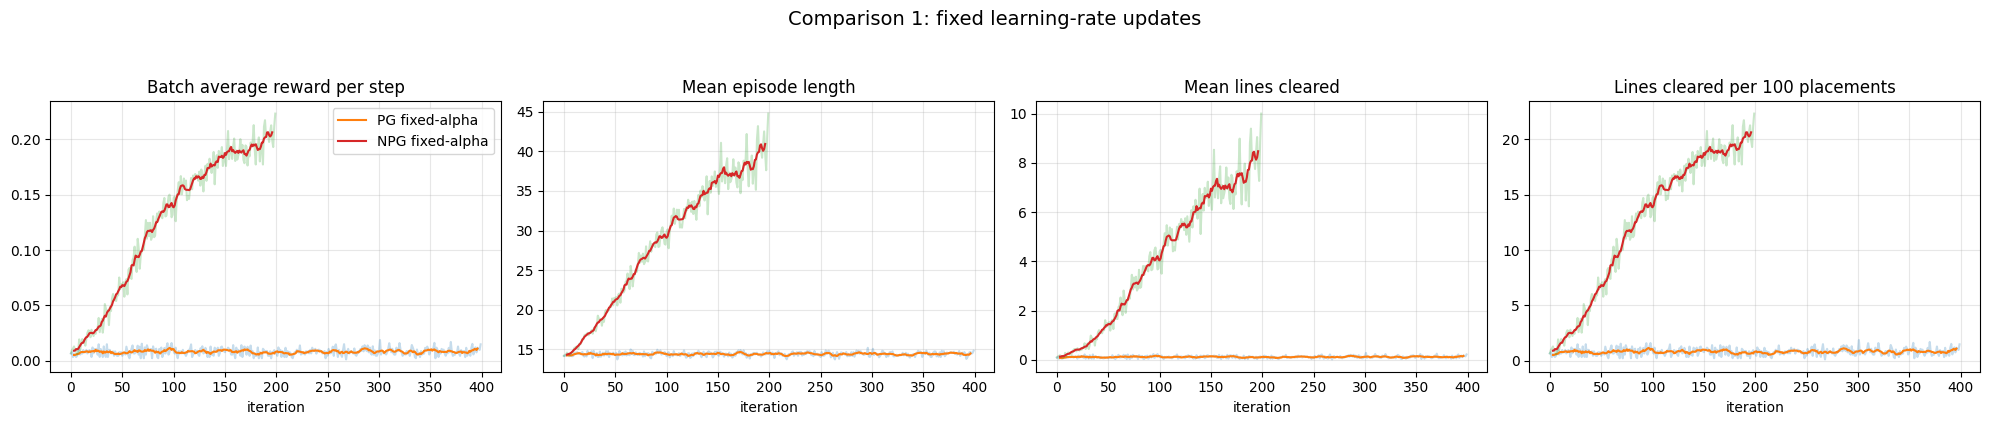

In [11]:
def moving_average(x, k=7):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k)/k, mode="valid")

def add_derived_metrics(hist):
    out = []
    for h in hist:
        h = dict(h)
        h["lines_per_step"] = h["mean_lines"] / max(h["mean_length"], 1e-8)
        h["lines_per_100_steps"] = 100.0 * h["lines_per_step"]
        h["score_per_100_steps"] = 100.0 * h["eta_hat"]
        out.append(h)
    return out

def plot_training(histories, labels, title=None, smooth=7):
    histories = [add_derived_metrics(h) for h in histories]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    metrics = ["eta_hat", "mean_length", "mean_lines", "lines_per_100_steps"]
    titles = [
        "Batch average reward per step",
        "Mean episode length",
        "Mean lines cleared",
        "Lines cleared per 100 placements",
    ]

    for ax, metric, ax_title in zip(axes, metrics, titles):
        for hist, label in zip(histories, labels):
            y = [h[metric] for h in hist]
            ax.plot(y, alpha=0.25)
            ma = moving_average(y, k=smooth)
            # Correct x-axis alignment: the moving average is centered
            offset = (smooth - 1) // 2
            ax.plot(range(offset, offset + len(ma)), ma, label=label)
        ax.set_title(ax_title)
        ax.set_xlabel("iteration")
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    if title is not None:
        fig.suptitle(title, y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training(
    [hist_pg_raw, hist_npg_raw],
    ["PG fixed-alpha", "NPG fixed-alpha"],
    title="Comparison 1: fixed learning-rate updates",
)


 PG iter 000 | eta +0.0066 | len 14.2 | lines 0.09 | steps 906 | target-KL 0.02
 PG iter 040 | eta +0.2070 | len 41.4 | lines 8.56 | steps 2647 | target-KL 0.02
 PG iter 080 | eta +0.2941 | len 77.5 | lines 22.78 | steps 4958 | target-KL 0.02
 PG iter 120 | eta +0.3312 | len 119.6 | lines 39.62 | steps 7657 | target-KL 0.02
 PG iter 160 | eta +0.3444 | len 145.5 | lines 50.11 | steps 9313 | target-KL 0.02
 PG iter 200 | eta +0.3537 | len 170.4 | lines 60.27 | steps 10905 | target-KL 0.02
 PG iter 240 | eta +0.3625 | len 183.1 | lines 66.39 | steps 11721 | target-KL 0.02
 PG iter 280 | eta +0.3643 | len 189.0 | lines 68.84 | steps 12093 | target-KL 0.02
 PG iter 320 | eta +0.3684 | len 206.6 | lines 76.11 | steps 13222 | target-KL 0.02
 PG iter 360 | eta +0.3590 | len 182.3 | lines 65.45 | steps 11668 | target-KL 0.02
 PG iter 399 | eta +0.3643 | len 192.2 | lines 70.02 | steps 12299 | target-KL 0.02
NPG iter 000 | eta +0.0066 | len 14.2 | lines 0.09 | steps 906 | target-KL 0.02
NPG ite

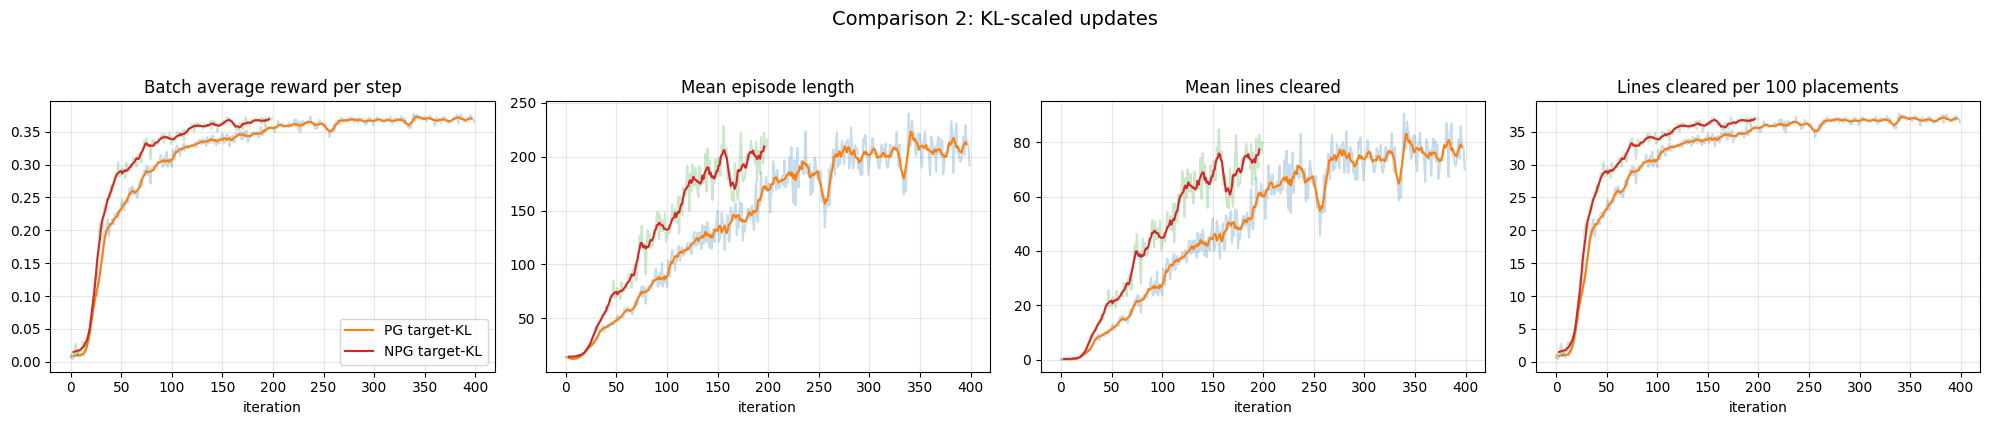

In [ ]:
# -----------------------------
# 6.2 KL-scaled comparison: both methods get the same local policy-distribution step
# -----------------------------

theta_pg_kl, hist_pg_kl = train(
    "pg",
    seed=SEED,
    n_iter=N_ITER_PG_KL,
    use_target_kl=True,
    target_kl=TARGET_KL,
)

theta_npg_kl, hist_npg_kl = train(
    "npg",
    seed=SEED,
    n_iter=N_ITER_NPG_KL,
    use_target_kl=True,
    target_kl=TARGET_KL,
)


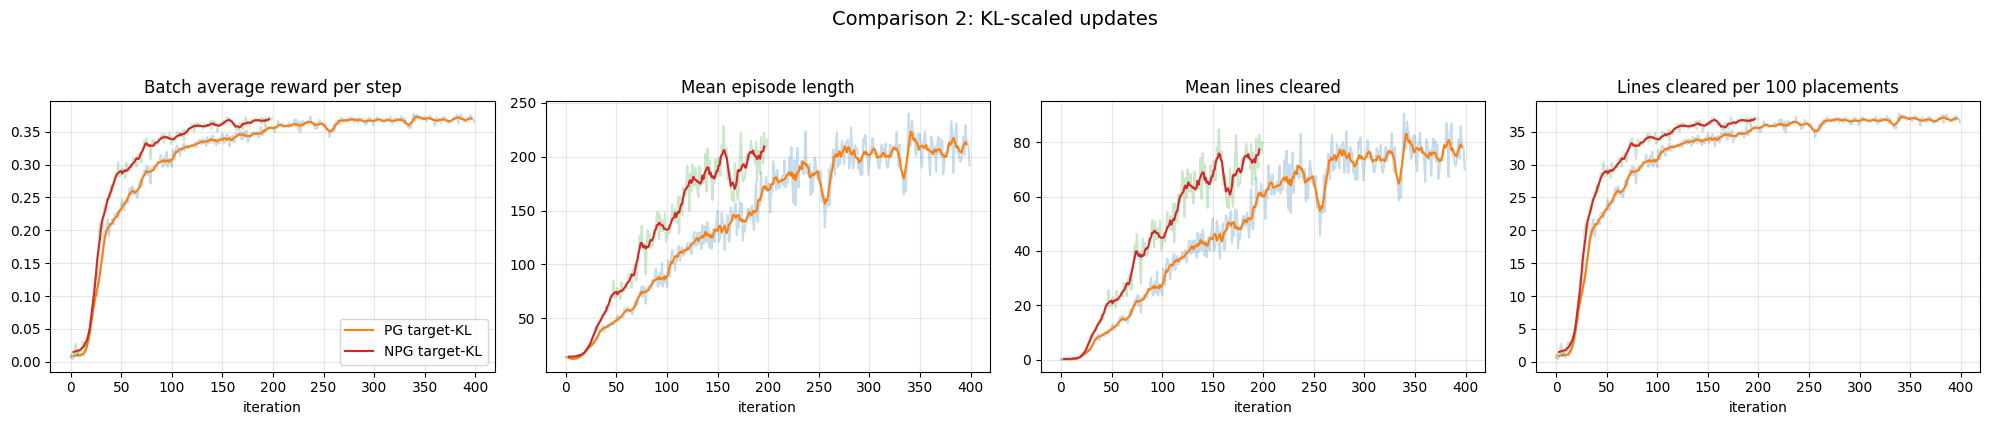

In [13]:
plot_training(
    [hist_pg_kl, hist_npg_kl],
    ["PG target-KL", "NPG target-KL"],
    title="Comparison 2: KL-scaled updates",
)

# Default aliases used in later sections.
# The greedy-limit visualization uses the KL-scaled NPG policy by default.
theta_pg, hist_pg = theta_pg_kl, hist_pg_kl
theta_npg, hist_npg = theta_npg_kl, hist_npg_kl


 ## 7. Empirical return landscapes in the PG/NPG plane



 The training curves show how the methods behave over time. The contour plots below ask a more local question:



 > If we move away from the current parameter vector in the two-dimensional plane spanned by the PG and NPG directions, what return do we actually get?



 At a fixed parameter vector $\theta$, we estimate



 $$

 d_{\mathrm{PG}} = g,

 \qquad

 d_{\mathrm{NPG}}=(F+\lambda I)^{-1}g.

 $$



 These two directions live in the full parameter space. We build a two-dimensional slice through $\theta$ using these directions. Each point $(u,v)$ in the plot corresponds to



 $$

 \theta_{\mathrm{test}}

 =

 \theta

 +

 u e_1

 +

 v e_2.

 $$



 For every grid point, we actually run evaluation episodes and plot the measured return. These contours are empirical Tetris performance, not just the linearized local model.



 We draw two versions:



 1. A contour around the fixed-learning-rate comparison, with fixed-alpha PG/NPG arrows.

 2. A contour around the KL-scaled comparison, with target-KL PG/NPG arrows.



 The empirical contour plot is expensive. If it is noisy, increase `eval_episodes`. If it is too slow, reduce `grid_size`.

Evaluating 225 grid points.
Each grid point uses 16 episodes.
Total evaluation episodes: 3600.
Arrow scaling: fixed alpha: PG=0.005, NPG=1
Empirical contour evaluation finished in 96.4s.


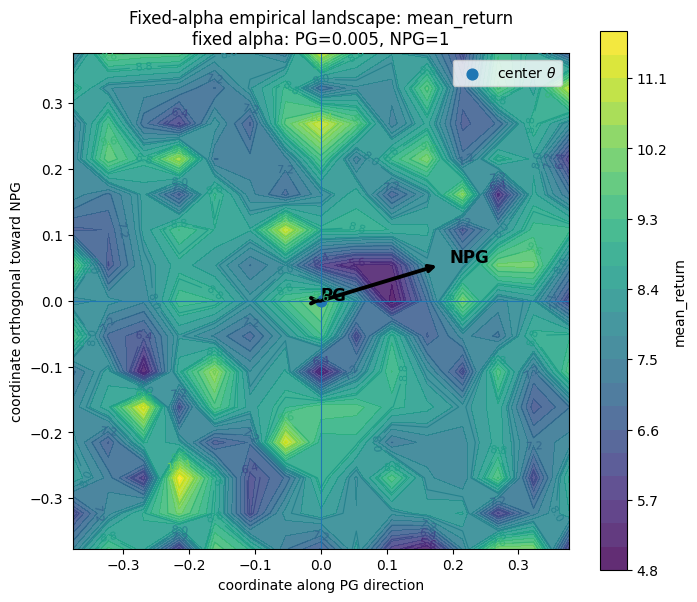

Center batch diagnostics
------------------------
eta_hat:        +0.200472
mean length:    39.75
mean lines:     7.97
n steps:        2544

Arrow diagnostics
-----------------
PG predicted improvement g^T delta:  +0.000000
NPG predicted improvement g^T delta: +0.000646

Empirical landscape diagnostics
-------------------------------
best mean_return:  +11.687500
Evaluating 225 grid points.
Each grid point uses 16 episodes.
Total evaluation episodes: 3600.
Arrow scaling: target-KL=0.02
Empirical contour evaluation finished in 521.7s.


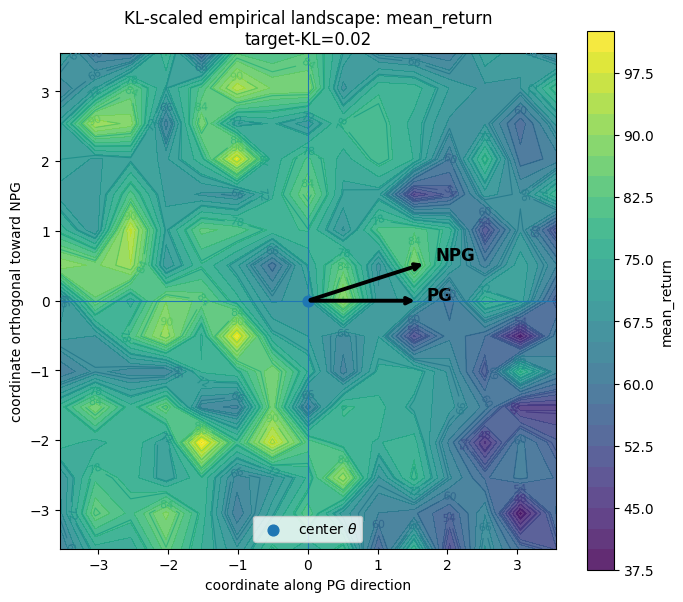

Center batch diagnostics
------------------------
eta_hat:        +0.369863
mean length:    216.72
mean lines:     80.16
n steps:        13870

Arrow diagnostics
-----------------
PG predicted improvement g^T delta:  +0.001153
NPG predicted improvement g^T delta: +0.001239

Empirical landscape diagnostics
-------------------------------
best mean_return:  +102.125000


In [ ]:
def orthonormal_basis_from(d1, d2, eps=1e-12):
    norm_d1 = np.linalg.norm(d1)
    if norm_d1 < eps:
        # PG direction is essentially zero; fall back to a random unit vector
        e1 = np.random.default_rng(SEED).normal(size=d1.shape)
        e1 /= np.linalg.norm(e1)
    else:
        e1 = d1 / norm_d1
        
    u2 = d2 - e1 * float(e1 @ d2)
    norm_u2 = np.linalg.norm(u2)
    
    if norm_u2 < eps:
        # NPG direction is nearly parallel to PG or zero; find any vector not parallel to e1
        for i in range(len(e1)):
            test = np.zeros_like(e1)
            test[i] = 1.0
            v = test - e1 * float(e1 @ test)
            if np.linalg.norm(v) > eps:
                u2 = v
                break
        else:
            u2 = np.random.default_rng(SEED).normal(size=e1.shape)
            u2 = u2 - e1 * float(e1 @ u2)
            
    e2 = u2 / np.linalg.norm(u2)
    return e1, e2

def evaluate_policy(theta, seed=SEED, n_episodes=10, max_steps=MAX_STEPS, temperature=1.0,
                    parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):
    """
    Evaluate a fixed policy by running full episodes.

    The result is noisy because Tetris pieces are random. Increase n_episodes
    for a cleaner contour plot.
    """
    eval_rng = np.random.default_rng(seed)
    episodes = collect_episodes(theta, eval_rng, batch_episodes=n_episodes,
                                max_steps=max_steps, temperature=temperature,
                                keep_first_for_viz=False,
                                parallel_rollouts=parallel_rollouts,
                                n_jobs=n_jobs)

    total_returns = np.array([sum(ep.rewards) for ep in episodes], dtype=float)
    lengths = np.array([ep.length for ep in episodes], dtype=float)
    lines = np.array([ep.lines for ep in episodes], dtype=float)
    all_rewards = np.array([r for ep in episodes for r in ep.rewards], dtype=float)

    return dict(
        mean_return=float(total_returns.mean()),
        mean_reward_per_step=float(all_rewards.mean()) if len(all_rewards) else float("-inf"),
        mean_length=float(lengths.mean()),
        mean_lines=float(lines.mean()),
    )

def _evaluate_grid_point(theta, e1, e2, u, v, seed, eval_episodes, max_steps, temperature, metric):
    theta_test = theta + u * e1 + v * e2
    info = evaluate_policy(theta_test, seed=seed, n_episodes=eval_episodes,
                           max_steps=max_steps, temperature=temperature,
                           parallel_rollouts=False, n_jobs=1)
    return info[metric], info

def make_arrow_deltas(d_pg, d_npg, F, use_target_kl=True, target_kl=TARGET_KL,
                      alpha_pg=ALPHA_PG_RAW, alpha_npg=ALPHA_NPG_RAW):
    if use_target_kl:
        pg_delta, _ = fisher_scaled_update(d_pg, F, target_kl)
        npg_delta, _ = fisher_scaled_update(d_npg, F, target_kl)
        desc = f"target-KL={target_kl:g}"
    else:
        pg_delta = alpha_pg * d_pg
        npg_delta = alpha_npg * d_npg
        desc = f"fixed alpha: PG={alpha_pg:g}, NPG={alpha_npg:g}"
    return pg_delta, npg_delta, desc

def empirical_return_contour(theta, seed=SEED + 100, damping=DAMPING, target_kl=TARGET_KL,
                             batch_episodes=BATCH_EPISODES, eval_episodes=32,
                             grid_size=15, radius_multiplier=2.0,
                             max_steps=MAX_STEPS, trace_decay=1.0,
                             temperature=1.0, metric="mean_return",
                             use_target_kl=True,
                             alpha_pg=ALPHA_PG_RAW, alpha_npg=ALPHA_NPG_RAW,
                             title_prefix="Empirical return landscape",
                             parallel_grid=True, n_jobs=N_JOBS):
    """
    Evaluate the empirical return landscape on the 2D plane spanned by PG and NPG.

    This is expensive: total evaluation episodes = grid_size^2 * eval_episodes.
    The evaluation itself is parallelized across grid points when possible.
    """
    local_rng = np.random.default_rng(seed)

    # Estimate local PG and NPG directions at the center theta.
    g, F, info = estimate_batch(theta, local_rng, batch_episodes=batch_episodes,
                                max_steps=max_steps, trace_decay=trace_decay,
                                temperature=temperature)

    d_pg = g
    d_npg = natural_direction(F, g, damping=damping)

    pg_delta, npg_delta, arrow_desc = make_arrow_deltas(
        d_pg, d_npg, F,
        use_target_kl=use_target_kl,
        target_kl=target_kl,
        alpha_pg=alpha_pg,
        alpha_npg=alpha_npg,
    )

    # Plane basis: e1 is PG, e2 is the component of NPG orthogonal to PG.
    e1, e2 = orthonormal_basis_from(d_pg, d_npg)

    pg_xy = np.array([float(pg_delta @ e1), float(pg_delta @ e2)])
    npg_xy = np.array([float(npg_delta @ e1), float(npg_delta @ e2)])

    arrow_scale = max(np.linalg.norm(pg_xy), np.linalg.norm(npg_xy), 1e-8)
    radius = radius_multiplier * arrow_scale

    us = np.linspace(-radius, radius, grid_size)
    vs = np.linspace(-radius, radius, grid_size)

    grid_points = []
    for i, v in enumerate(vs):
        for j, u in enumerate(us):
            point_seed = int(seed + 100000 + i * grid_size + j)
            grid_points.append((i, j, float(u), float(v), point_seed))

    print(f"Evaluating {len(grid_points)} grid points.")
    print(f"Each grid point uses {eval_episodes} episodes.")
    print(f"Total evaluation episodes: {len(grid_points) * eval_episodes}.")
    print(f"Arrow scaling: {arrow_desc}")

    start = time.time()

    use_parallel = parallel_grid and JOBLIB_AVAILABLE and n_jobs != 1 and len(grid_points) > 1
    if use_parallel:
        results = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(_evaluate_grid_point)(
                theta, e1, e2, u, v, point_seed,
                eval_episodes, max_steps, temperature, metric
            )
            for (i, j, u, v, point_seed) in grid_points
        )
    else:
        results = [
            _evaluate_grid_point(theta, e1, e2, u, v, point_seed,
                                 eval_episodes, max_steps, temperature, metric)
            for (i, j, u, v, point_seed) in grid_points
        ]

    Z = np.zeros((grid_size, grid_size), dtype=float)
    full_info = [[None for _ in range(grid_size)] for _ in range(grid_size)]

    for (i, j, u, v, point_seed), (value, eval_info) in zip(grid_points, results):
        Z[i, j] = value
        full_info[i][j] = eval_info

    elapsed = time.time() - start
    print(f"Empirical contour evaluation finished in {elapsed:.1f}s.")

    U, V = np.meshgrid(us, vs)

    fig, ax = plt.subplots(figsize=(8, 7))
    cf = ax.contourf(U, V, Z, levels=25, alpha=0.85)
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(metric)

    cs = ax.contour(U, V, Z, levels=10, linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=8)

    ax.scatter([0.0], [0.0], s=60, label=r"center $\theta$")

    # ---- Arrow drawing: true scale (solid) + direction indicator (dashed) ----
    indicator_length = 0.3 * radius   # fixed length for the dashed direction line

    def draw_arrow_with_direction(xy, label, actual_delta):
        norm_xy = np.linalg.norm(xy)
        if norm_xy < 1e-12:
            return  # no direction to show
        direction = xy / norm_xy

        # 1. True-scale solid arrow (can be very short)
        ax.annotate("", xy=xy, xytext=(0.0, 0.0),
                    arrowprops=dict(arrowstyle="->", linewidth=2.5, color='black'))

        # 2. Dashed direction line of fixed length
        dir_end = indicator_length * direction
        ax.plot([0, dir_end[0]], [0, dir_end[1]],
                linestyle='--', linewidth=1.5, color='grey', alpha=0.8)

        # 3. Label near the tip of the dashed line
        ax.text(1.05 * dir_end[0], 1.05 * dir_end[1],
                f"{label} (Δ≈{norm_xy:.2e})", fontsize=11, weight="bold",
                ha='left' if dir_end[0] >= 0 else 'right')

    # Draw PG and NPG
    draw_arrow_with_direction(pg_xy, "PG", np.linalg.norm(pg_xy))
    draw_arrow_with_direction(npg_xy, "NPG", np.linalg.norm(npg_xy))

    ax.axhline(0.0, linewidth=0.8)
    ax.axvline(0.0, linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"coordinate along PG direction")
    ax.set_ylabel(r"coordinate orthogonal toward NPG")
    ax.set_title(f"{title_prefix}: {metric}\n{arrow_desc}")
    ax.legend(loc="best")
    plt.show()

    print("Center batch diagnostics")
    print("------------------------")
    print(f"eta_hat:        {info['eta_hat']:+.6f}")
    print(f"mean length:    {info['mean_length']:.2f}")
    print(f"mean lines:     {info['mean_lines']:.2f}")
    print(f"n steps:        {info['n_steps']}")
    print()
    print("Arrow diagnostics")
    print("-----------------")
    print(f"PG predicted improvement g^T delta:  {float(g @ pg_delta):+.6f}")
    print(f"NPG predicted improvement g^T delta: {float(g @ npg_delta):+.6f}")
    print()
    print("Empirical landscape diagnostics")
    print("-------------------------------")
    print(f"best {metric}:  {float(np.max(Z)):+.6f}")

    return dict(
        g=g,
        F=F,
        d_pg=d_pg,
        d_npg=d_npg,
        pg_delta=pg_delta,
        npg_delta=npg_delta,
        pg_xy=pg_xy,
        npg_xy=npg_xy,
        e1=e1,
        e2=e2,
        us=us,
        vs=vs,
        Z=Z,
        eval_info=full_info,
        center_info=info,
        use_target_kl=use_target_kl,
        arrow_desc=arrow_desc,
    )

# A modest default. Increase grid_size and eval_episodes for a cleaner but slower plot.
landscape_raw = empirical_return_contour(
    theta_npg_raw,
    seed=SEED + 100,
    eval_episodes=32,
    grid_size=15,
    radius_multiplier=2.0,
    metric="mean_return",
    use_target_kl=False,
    alpha_pg=ALPHA_PG_RAW,
    alpha_npg=ALPHA_NPG_RAW,
    title_prefix="Fixed-alpha empirical landscape",
)

landscape_kl = empirical_return_contour(
    theta_npg_kl,
    seed=SEED + 200,
    eval_episodes=32,
    grid_size=15,
    radius_multiplier=2.0,
    metric="mean_return",
    use_target_kl=True,
    target_kl=TARGET_KL,
    title_prefix="KL-scaled empirical landscape",
)


 ## 8. Visualizing the greedy-action limit



 For a softmax policy,



 $$

 \pi_{\theta+\alpha w}(a|s)

 \propto

 \exp(\theta^\top\phi_{s,a}+\alpha w^\top\phi_{s,a}).

 $$



 If $w=\widetilde{\nabla}\eta(\theta)$, then $w$ is also the compatible-function-approximation weight vector.



 For a fixed state, we can compute



 $$

 f^\pi(s,a;w)=w^\top(\phi_{s,a}-\mathbb{E}_\pi[\phi_{s,\cdot}]).

 $$



 Since the expectation term does not depend on $a$, ranking by $f^\pi(s,a;w)$ is the same as ranking by $w^\top\phi_{s,a}$.



 The visualization below shows that as $\alpha$ grows, the policy mass moves toward the actions that maximize $f^\pi(s,a;w)$.



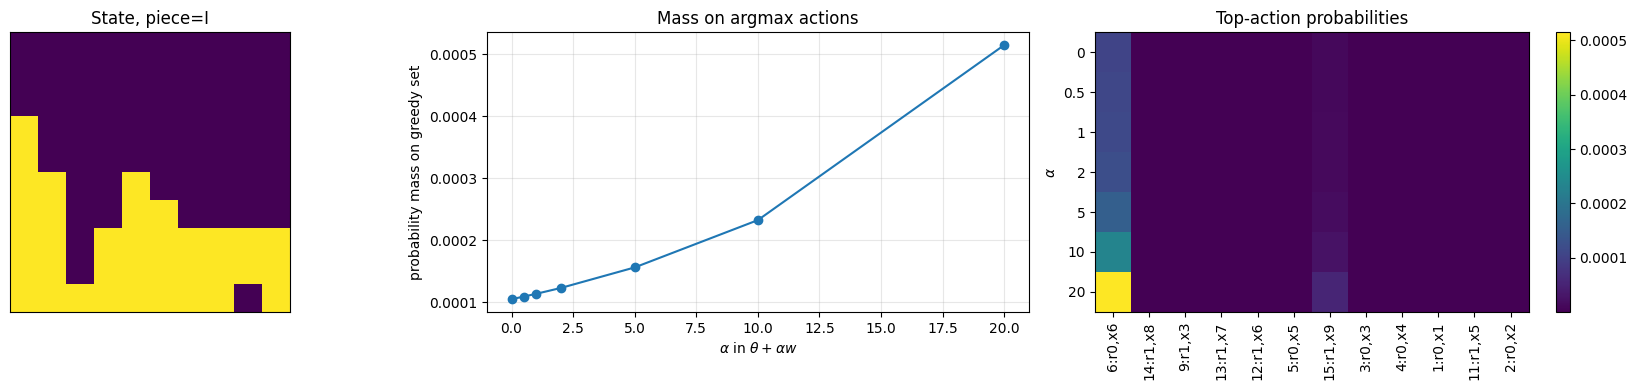

Top actions ranked by compatible approximation f(s,a;w):
 1. action  6 rot=0 x= 6 f=+0.0795 p0=0.0001
 2. action 14 rot=1 x= 8 f=+0.0777 p0=0.0000
 3. action  9 rot=1 x= 3 f=+0.0775 p0=0.0000
 4. action 13 rot=1 x= 7 f=+0.0774 p0=0.0000
 5. action 12 rot=1 x= 6 f=+0.0772 p0=0.0000
 6. action  5 rot=0 x= 5 f=+0.0772 p0=0.0000
 7. action 15 rot=1 x= 9 f=+0.0768 p0=0.0000
 8. action  3 rot=0 x= 3 f=+0.0753 p0=0.0000
 9. action  4 rot=0 x= 4 f=+0.0753 p0=0.0000
10. action  1 rot=0 x= 1 f=+0.0752 p0=0.0000


In [15]:
def find_interesting_state(theta, seed=SEED + 10, burn_in=30):
    local_rng = np.random.default_rng(seed)
    board = empty_board()
    saved = None
    for t in range(burn_in):
        piece_id = int(local_rng.integers(len(PIECE_NAMES)))
        actions = attach_features(legal_afterstates(board, piece_id))
        if len(actions) == 0:
            board = empty_board()
            continue
        if len(actions) >= 6:
            saved = dict(board=board.copy(), piece_id=piece_id, actions=actions)
        idx, probs, score, phis, logits = sample_policy_action(theta, actions, local_rng)
        board = actions[idx]["board"]
    if saved is None:
        # fallback empty board
        piece_id = int(local_rng.integers(len(PIECE_NAMES)))
        saved = dict(board=empty_board(), piece_id=piece_id,
                     actions=attach_features(legal_afterstates(empty_board(), piece_id)))
    return saved

def compute_current_npg(theta, seed=SEED + 20):
    local_rng = np.random.default_rng(seed)
    g, F, info = estimate_batch(theta, local_rng, batch_episodes=BATCH_EPISODES, max_steps=MAX_STEPS)
    w = natural_direction(F, g, damping=DAMPING)
    return w, g, F, info

def plot_greedy_limit(theta, state, w, alphas=(0, 0.5, 1, 2, 5, 10, 20), top_k=12):
    actions = state["actions"]
    phis = np.stack([a["phi"] for a in actions], axis=0)
    probs0, expected_phi, logits0 = policy_distribution(theta, phis)
    psi = phis - expected_phi
    fvals = psi @ w

    order = np.argsort(-fvals)
    greedy_val = fvals[order[0]]
    greedy_set = np.where(np.isclose(fvals, greedy_val, atol=1e-8))[0]

    top = order[:min(top_k, len(order))]
    labels = [f"{i}:r{actions[i]['rot_id']},x{actions[i]['x']}" for i in top]

    mass_on_greedy = []
    prob_matrix = []
    for a in alphas:
        probs, _, _ = policy_distribution(theta + a*w, phis)
        mass_on_greedy.append(probs[greedy_set].sum())
        prob_matrix.append(probs[top])
    prob_matrix = np.array(prob_matrix)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    render_board(state["board"], ax=axes[0], title=f"State, piece={PIECE_NAMES[state['piece_id']]}")

    axes[1].plot(alphas, mass_on_greedy, marker="o")
    axes[1].set_xlabel(r"$\alpha$ in $\theta+\alpha w$")
    axes[1].set_ylabel("probability mass on greedy set")
    axes[1].set_title("Mass on argmax actions")
    axes[1].grid(True, alpha=0.3)

    im = axes[2].imshow(prob_matrix, aspect="auto", interpolation="nearest")
    axes[2].set_yticks(range(len(alphas)))
    axes[2].set_yticklabels([str(a) for a in alphas])
    axes[2].set_xticks(range(len(top)))
    axes[2].set_xticklabels(labels, rotation=90)
    axes[2].set_ylabel(r"$\alpha$")
    axes[2].set_title("Top-action probabilities")
    fig.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

    print("Top actions ranked by compatible approximation f(s,a;w):")
    for rank, i in enumerate(order[:10]):
        print(f"{rank+1:2d}. action {i:2d} rot={actions[i]['rot_id']} x={actions[i]['x']:2d} "
              f"f={fvals[i]:+.4f} p0={probs0[i]:.4f}")

w_npg, g_for_w, F_for_w, info_for_w = compute_current_npg(theta_npg)
state = find_interesting_state(theta_npg)
plot_greedy_limit(theta_npg, state, w_npg)